# Different models for different performace

### Some guiding principles
- Size of a dataset
    - fewer features = simpler model , faster training time
    - some models require large amount of data to perform well
- Interpretability
    - Some models are easier to explain , which can be important for stakeholders 
    - Linear regression has high interpretability as we can understand the coefficients
- Flexibility 
    - May improve accuracy by making fewer assumptions about the data
    - KNN is a more flexible model , doesn't assume any linear relationships

## Its all in the metrics
- Regression model Performance
    - RMSE
    - R-Squared 
- Classification model performance 
    - Accuracy 
    - Confusion Matrix 
    - Precision , Recall , F1-score
    - ROC AUC
- Train several models and evaluate performance out of the box

## A note on scaling 
- Models affected by scalling :
    - KNN
    - Linear Regression (plus Ridge , Lasso)
    - Logistic Regression
    - Artificial Neural Network

- Best to scale our data before evaluating models



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score , KFold
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [2]:
music_df = pd.read_csv(r'F:\mubashir\Coding\Machine Learning\Sickit Learn\Supervised Learning\4. Processing Data\Cleaning Data\spotify_songs_dataset.csv')
music_dummies = pd.get_dummies(music_df['genre'],drop_first=True)
music_dummies = pd.concat([music_df,music_dummies],axis=1)
music_dummies = music_dummies.drop('genre',axis=1)
music_df = music_df.dropna(subset=['language','duration','collaboration'])
drop_cols = [
    'song_id',
    'song_title',
    'artist',
    'album',
    'release_date',
    'language',
    'explicit_content',
    'composer',
    'producer',
    'collaboration',
    'label',
    'stream'
]

music_clean = music_dummies.drop(columns=drop_cols)
music_clean = music_clean.dropna()
feature = music_clean.drop('popularity',axis=1).values
target = music_clean['popularity'].values

In [6]:

X_train , X_test , y_train , y_test = train_test_split(feature,target,test_size=0.2,random_state=42)
scaler = StandardScaler()
X_trained_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_8200\3802901423.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results,labels=models.keys())


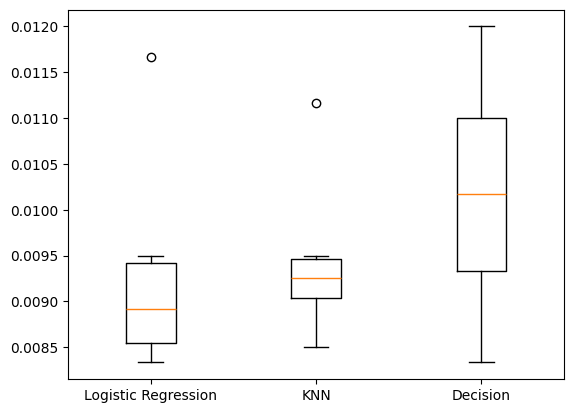

In [7]:
models = {"Logistic Regression" : LogisticRegression(),
          "KNN" : KNeighborsClassifier(),
          "Decision" : DecisionTreeClassifier()}

results = []

for model in models.values() :
    kf = KFold(n_splits=6,random_state=42,shuffle=True)
    cv_results = cross_val_score(model,X_trained_scaled,y_train,cv=kf)
    results.append(cv_results)
plt.boxplot(results,labels=models.keys())
plt.show()

In [9]:
for name , model in models.items() :
    model.fit(X_trained_scaled,y_train)
    test_score = model.score(X_test_scaled,y_test)
    print("{} Test score accuracy: {}".format(name,test_score))

Logistic Regression Test score accuracy: 0.010666666666666666
KNN Test score accuracy: 0.008555555555555556
Decision Test score accuracy: 0.009777777777777778
